In [6]:
from functools import partial
from typing import Union

import chex
import jax
import jax.numpy as jnp
from flax.training.train_state import TrainState  
from jax.tree import map as tree_map
from matplotlib import pyplot as plt
from tqdm import tqdm
import numpy as np

# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# os.environ['JAX_PLATFORMS']='cpu'
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')

from run_pinns import *
from collections import defaultdict


#from load_metrics import load_metrics
import matplotlib.pyplot as plt

In [7]:
def plot_loss_and_error(history_groups, colors, error_every=100, max_valid_steps=500):
    """
    Plot training loss and L2 error side-by-side for multiple solver groups.

    Args:
        history_groups: list of (history_dict, linestyle, alpha)
        colors: function taking int -> color
        error_every: frequency of l2_error recording (default every 100 epochs)
        max_valid_steps: max steps to plot if NaNs are detected
    """
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey="row")
    ax_loss, ax_error, ax_error_pde, ax_error_bc = axes

    color_offset = 0

    for group_idx, (history_dict, linestyle, alpha) in enumerate(history_groups):
        for i, (slvr, metrics) in enumerate(history_dict.items()):
            #idx = color_offset + i
            idx = i

            # --- Loss ---
            loss_arr = np.array(metrics['train_loss'])

            nan = ''
            if np.isnan(np.min(loss_arr)):
                loss_arr = loss_arr[:max_valid_steps]
                nan = '(NaNs)'
                
            ax_loss.semilogy(
                loss_arr,
                label=f"{slvr}{nan}",
                linestyle=linestyle,
                color=colors(idx),
                alpha=alpha
            )

            # --- Total Error ---
            errors = np.array(metrics.get('l2_error', []))
            nan = ''
            if np.isnan(np.min(errors)):
                errors = errors[:max_valid_steps // error_every]
                nan = '(NaNs)'
                
            x_vals = np.arange(0, len(errors)) * error_every
            ax_error.semilogy(
                x_vals, errors,
                label=f"{slvr}{nan}",
                linestyle=linestyle,
                color=colors(idx),
                alpha=alpha
            )

            # --- PDE Error ---
            errors = np.array(metrics.get('l2_error_pde', []))
            nan = ''
            if np.isnan(np.min(errors)):
                errors = errors[:max_valid_steps // error_every]
                nan = '(NaNs)'
                
            x_vals = np.arange(0, len(errors)) * error_every
            ax_error_pde.semilogy(
                x_vals, errors,
                label=f"{slvr}{nan}",
                linestyle=linestyle,
                color=colors(idx),
                alpha=alpha
            )

            # --- BC Error ---
            errors = np.array(metrics.get('l2_error_bc', []))
            nan = ''
            if np.isnan(np.min(errors)):
                errors = errors[:max_valid_steps // error_every]
                nan = '(NaNs)'
                
            x_vals = np.arange(0, len(errors)) * error_every
            ax_error_bc.semilogy(
                x_vals, errors,
                label=f"{slvr}{nan}",
                linestyle=linestyle,
                color=colors(idx),
                alpha=alpha
            )

        color_offset += len(history_dict)

    ax_loss.set_title('Training Loss')
    ax_error.set_title('L2 Error')
    ax_error_pde.set_title('L2 Error (PDE)')
    ax_error_bc.set_title('L2 Error (BC)')

    
    for ax in axes:
        ax.set_xlabel('Epoch')
        ax.grid()
    
    ax.legend()

    plt.tight_layout()
    plt.show()


In [8]:
import os
import re
import pickle

def load_metrics(filepath):
    with open(filepath, 'rb') as f:
        return pickle.load(f)

def parse_desc(filename):
    # Extract all numbers from the filename
    numbers = list(map(int, re.findall(r'\d+', filename)))
    return tuple(numbers)

def load_all_metrics(path):
    metrics_history_sgd = {}
    for fname in os.listdir(path):
        if fname.endswith('.pkl'):
            name = fname[:-4]  # Remove '.pkl'
            desc = parse_desc(name)
            metrics = load_metrics(os.path.join(path, fname))
            metrics_history_sgd[name] = (desc, metrics)
    return metrics_history_sgd

def load_metrics_grouped_by_fx_fy(path):
    grouped_metrics = defaultdict(dict)  # (fx, fy) -> { label : metrics }

    for fname in os.listdir(path):
        if fname.endswith('.pkl'):
            name = fname[:-4]  # remove '.pkl'
            fx, fy, n_int, n_bnd = parse_desc(name)
            metrics = load_metrics(os.path.join(path, fname))
            label = f"int{n_int}_bnd{n_bnd}"
            grouped_metrics[(fx, fy)][label] = metrics

    return grouped_metrics


In [9]:

def smooth_loss(data, window_width=20):
    """
    Smooths noisy loss data using a moving average.

    Args:
        data (array-like): 1D sequence of loss values.
        window_width (int): Width of the smoothing window (must be odd).

    Returns:
        np.ndarray: Smoothed loss data.
    """
    data = np.asarray(data)
    if window_width < 1:
        raise ValueError("window_width must be at least 1")
    if window_width % 2 == 0:
        window_width += 1  # make it odd for symmetric smoothing

    pad = window_width // 2
    padded_data = np.pad(data, pad_width=pad, mode='edge')
    kernel = np.ones(window_width) / window_width
    return np.convolve(padded_data, kernel, mode='valid')

def plot_all_fx_fy(grouped_metrics, colors, error_every=100, max_valid_steps=500):
    """
    Plot training loss and errors for each (fx, fy) group on separate rows.

    Args:
        grouped_metrics: dict mapping (fx, fy) -> {label: metrics}
        colors: function taking int -> color
        error_every: frequency of l2_error recording
        max_valid_steps: maximum number of steps to plot if NaNs are detected
    """
    num_groups = len(grouped_metrics)
    fig, axes = plt.subplots(
        num_groups, 4, figsize=(16, 4 * num_groups),
        squeeze=False, sharey='col'
    )

    for row_idx, ((fx, fy), history_dict) in enumerate(sorted(grouped_metrics.items())):
        ax_loss, ax_error, ax_error_pde, ax_error_bc = axes[row_idx]

        for idx, (label, metrics) in enumerate(history_dict.items()):
            # --- Loss ---

            loss_arr = smooth_loss(np.array(metrics['train_loss']), 30)
            nan = ''
            if np.isnan(np.min(loss_arr)):
                loss_arr = loss_arr[:max_valid_steps]
                nan = '(NaNs)'
            else:
                loss_arr = loss_arr[::200]
            x_vals = np.arange(0, len(loss_arr)) * error_every


            ax_loss.semilogy(
                x_vals,
                loss_arr,
                label=f"{label}{nan}",
                color=colors(idx),
                linestyle='solid',
                alpha=0.3
            )

            # --- Total L2 Error ---
            errors = smooth_loss(np.array(metrics.get('l2_error', [])))
            if np.isnan(np.min(errors)):
                errors = errors[:max_valid_steps // error_every]
                nan = '(NaNs)'
            x_vals = np.arange(0, len(errors)) * error_every
            ax_error.semilogy(
                x_vals, errors,
                label=f"{label}{nan}",
                color=colors(idx),
                linestyle='solid',
                alpha=0.3
            )

            # --- PDE Error ---
            errors_pde = smooth_loss(np.array(metrics.get('l2_error_pde', [])))
            if np.isnan(np.min(errors_pde)):
                errors_pde = errors_pde[:max_valid_steps // error_every]
                nan = '(NaNs)'
            x_vals_pde = np.arange(0, len(errors_pde)) * error_every
            ax_error_pde.semilogy(
                x_vals_pde, errors_pde,
                label=f"{label}{nan}",
                color=colors(idx),
                linestyle='solid',
                alpha=0.3
            )

            # --- BC Error ---
            errors_bc = smooth_loss(np.array(metrics.get('l2_error_bc', [])))
            if np.isnan(np.min(errors_bc)):
                errors_bc = errors_bc[:max_valid_steps // error_every]
                nan = '(NaNs)'
            x_vals_bc = np.arange(0, len(errors_bc)) * error_every
            ax_error_bc.semilogy(
                x_vals_bc, errors_bc,
                label=f"{label}{nan}",
                color=colors(idx),
                linestyle='solid',
                alpha=0.3
            )

        # Set titles per column
        if row_idx == 0:
            ax_loss.set_title('Training Loss')
            ax_error.set_title('L2 Error')
            ax_error_pde.set_title('L2 Error (PDE)')
            ax_error_bc.set_title('L2 Error (BC)')

        # Set y-labels
        ax_loss.set_ylabel(f"(fx, fy) = ({fx}, {fy})")

        for ax in [ax_loss, ax_error, ax_error_pde, ax_error_bc]:
            ax.grid(True)
            ax.set_xlabel('Epoch')

        ax_loss.legend(fontsize='small', loc='best')

    plt.tight_layout()
    plt.show()


In [10]:
results = { "sgd" : load_metrics_grouped_by_fx_fy("sgd"),
            "gn"  : load_metrics_grouped_by_fx_fy("gn"),
            "smw" : load_metrics_grouped_by_fx_fy("smw")}

In [11]:
# metrics_history_sgd = load_metrics_grouped_by_fx_fy("sgd")
# metrics_history_sgd


# n_curves = len(metrics_history_sgd[(2,2)])
# colors = plt.cm.get_cmap('tab10', n_curves)


# plot_all_fx_fy(metrics_history_sgd, colors, error_every=100, max_valid_steps=500)

In [12]:


def regroup_by_int_prefix(grouped_metrics):
    regrouped = {}

    for fx_fy, inner_dict in grouped_metrics.items():
        int_group = defaultdict(dict)

        for label, metrics in inner_dict.items():
            match = re.match(r'int(\d+)_bnd(\d+)', label)
            if match:
                n_int = int(match.group(1))
                int_group[n_int][label] = metrics

        regrouped[fx_fy] = dict(int_group)

    return regrouped


regrouped_results = {}

for k, v in results.items():
    regrouped_results[k] = regroup_by_int_prefix(v)


/var/folders/jc/hbh56n2114d44h5k85mrw9sr003gz4/T/ipykernel_65685/3481472296.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Accent', 3)


##################################################
# sgd
##################################################


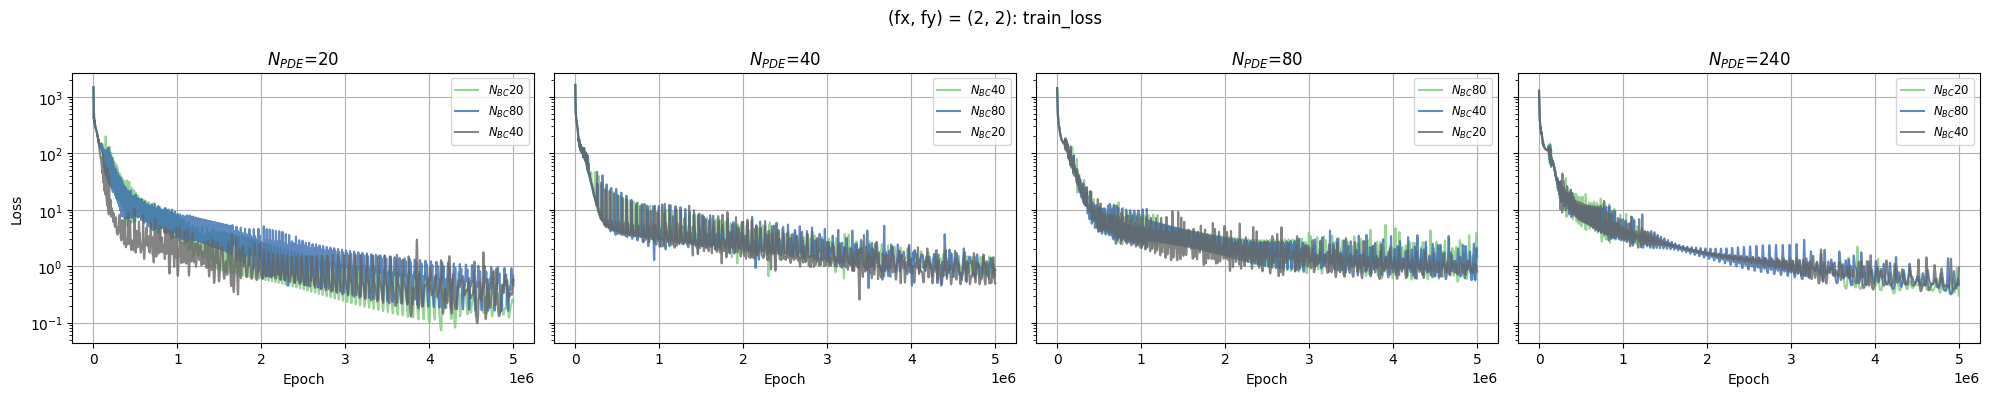

##################################################
# smw
##################################################


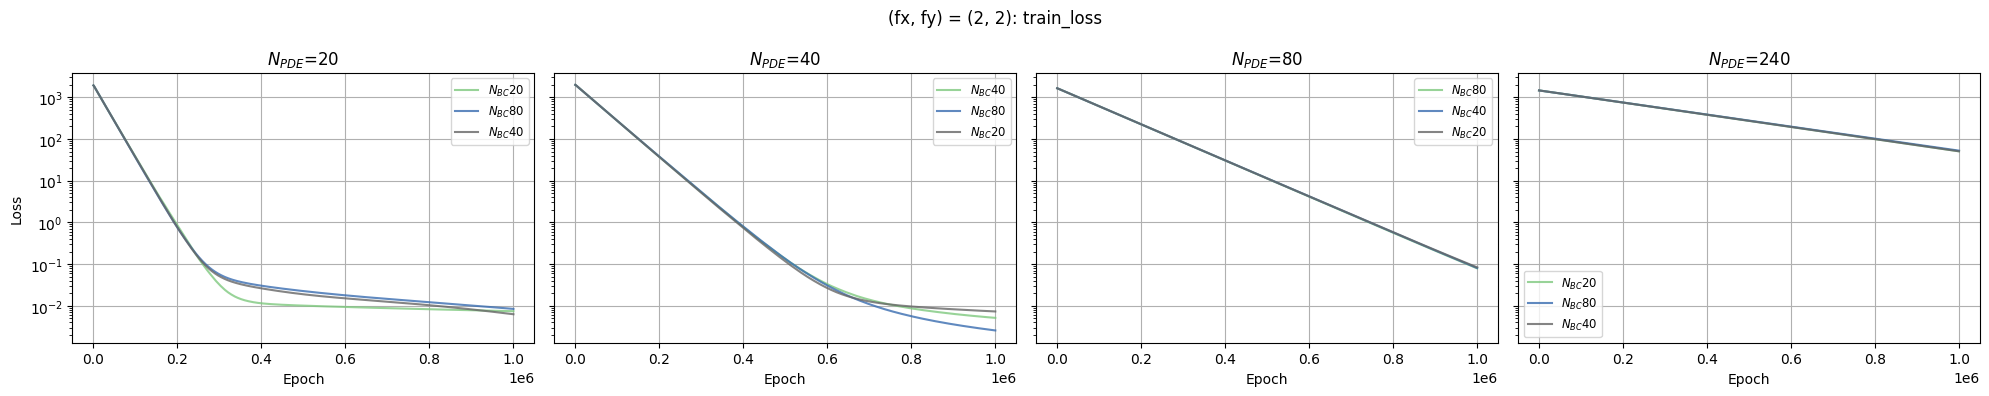

In [120]:

def plot_regrouped_by_int(grouped_metrics, colors, metric_label='train_loss', error_every=100, max_valid_steps=500):
    """
    Plot training loss and errors for regrouped metrics:
    - Each (fx, fy) pair is a new row.
    - Each column corresponds to a different intX group.

    Args:
        grouped_metrics: dict mapping (fx, fy) -> { intX -> { label: metrics } }
        colors: function taking int -> color
        error_every: frequency of l2_error recording
        max_valid_steps: maximum number of steps to plot if NaNs are detected
    """
    num_rows = len(grouped_metrics)

    for row_idx, ((fx, fy), int_groups) in enumerate(sorted(grouped_metrics.items())):

        if (fx, fy) == (1,1): continue
        
        int_keys = sorted(int_groups.keys())
        num_cols = len(int_keys)

        fig, axes = plt.subplots(
            1, num_cols, figsize=(5 * num_cols, 4),
            sharey=True, squeeze=False
        )

        for col_idx, intX in enumerate(int_keys):
            ax = axes[0, col_idx]
            label_dict = int_groups[intX]

            for idx, (label, metrics) in enumerate(label_dict.items()):
                #print(np.array(metrics.keys()))
                # --- Smooth loss ---
                loss_arr = smooth_loss(np.array(metrics[metric_label]), 30)
                nan = ''
                if np.isnan(np.min(loss_arr)):
                    loss_arr = loss_arr[:max_valid_steps]
                    nan = '(NaNs)'
                else:
                    loss_arr = loss_arr
                x_vals = np.arange(0, len(loss_arr)) * error_every

                l = label.split("_")[-1].split("bnd")[-1]
                ax.semilogy(
                    x_vals,
                    loss_arr,
                    label=("$N_{BC}$" + f"{l}{nan}"),
                    color=colors(idx),
                    linestyle='solid',
                    alpha=0.8
                )

            ax.set_title("$N_{PDE}$" + f"={intX}")
            ax.set_xlabel('Epoch')
            ax.grid(True)
            ax.legend(fontsize='small')

        axes[0, 0].set_ylabel('Loss')

        plt.suptitle(f"(fx, fy) = ({fx}, {fy}): {metric_label}")
        plt.tight_layout()
        plt.show()


colors = plt.cm.get_cmap('Accent', 3)
for k, v in regrouped_results.items():
    if k == "gn": continue
    print("""##################################################\n"""
          f"""# {k}\n"""
          """##################################################""")
    plot_regrouped_by_int(v, colors, error_every=100, max_valid_steps=500)


##################################################
# sgd
##################################################


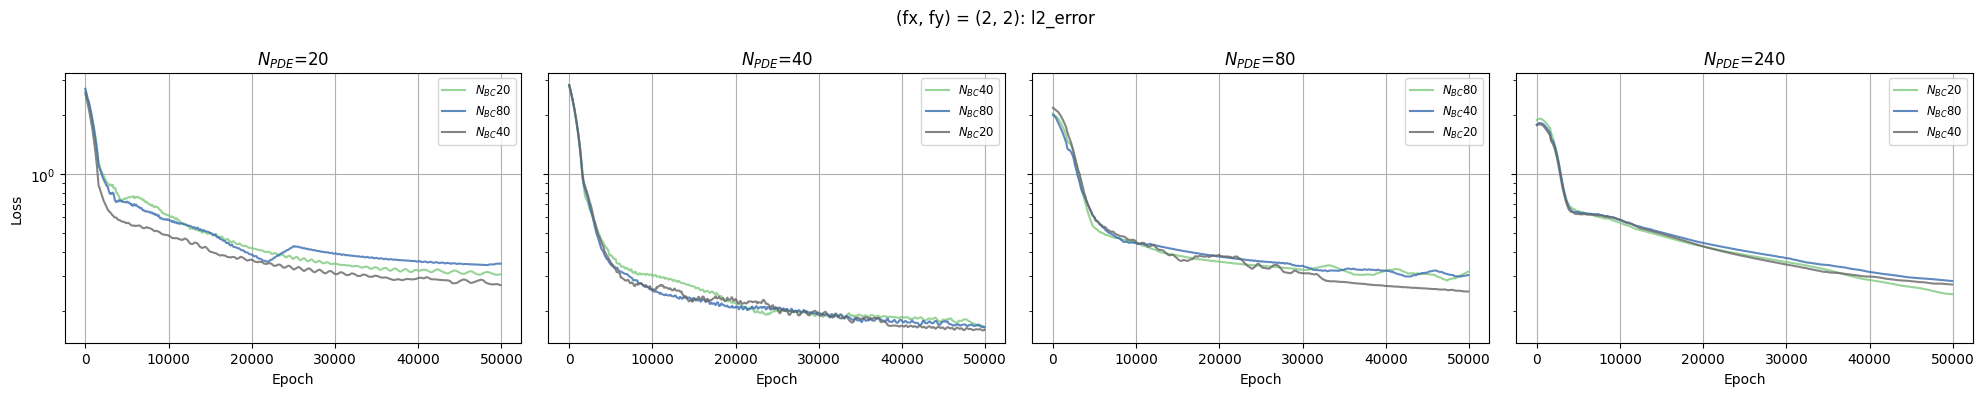

##################################################
# smw
##################################################


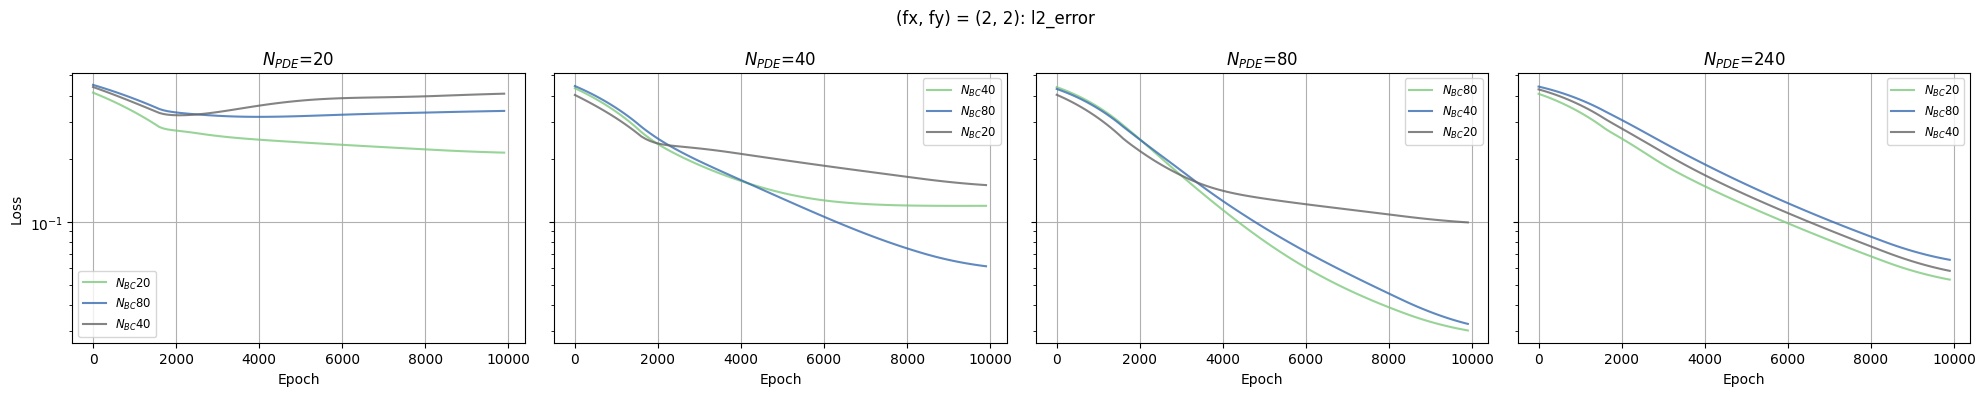

In [121]:

for k, v in regrouped_results.items():
    if k == "gn": continue
    print("""##################################################\n"""
          f"""# {k}\n"""
          """##################################################""")
    plot_regrouped_by_int(v, colors, metric_label="l2_error", error_every=100, max_valid_steps=500)

##################################################
# sgd
##################################################


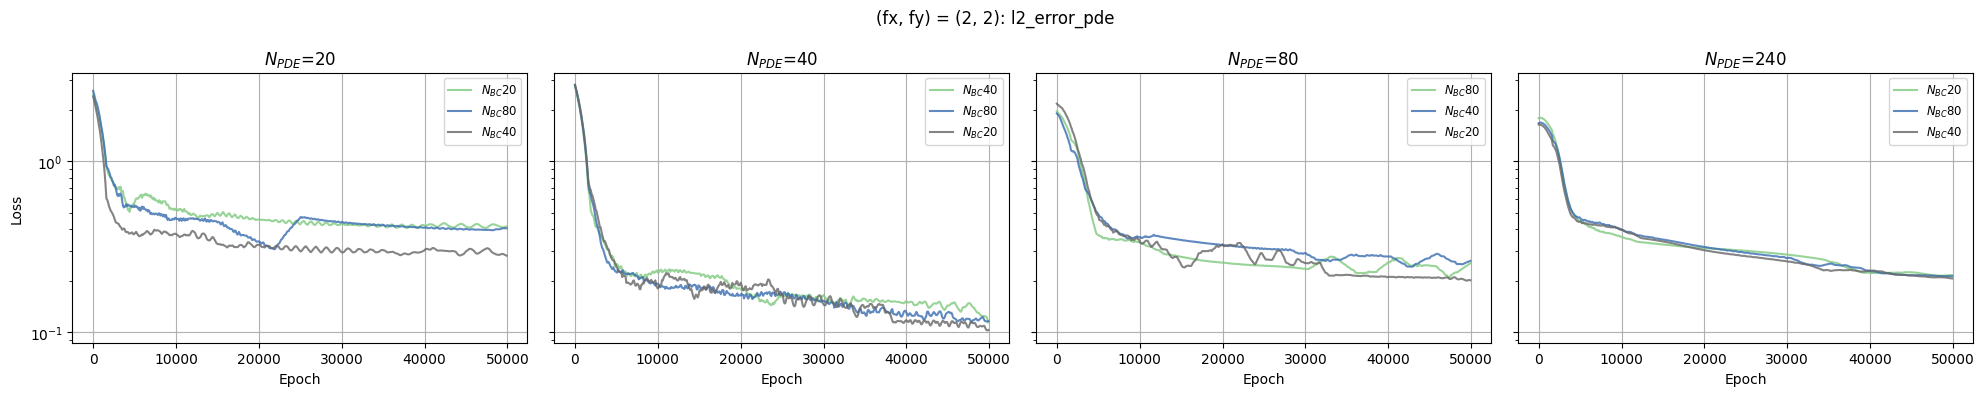

##################################################
# smw
##################################################


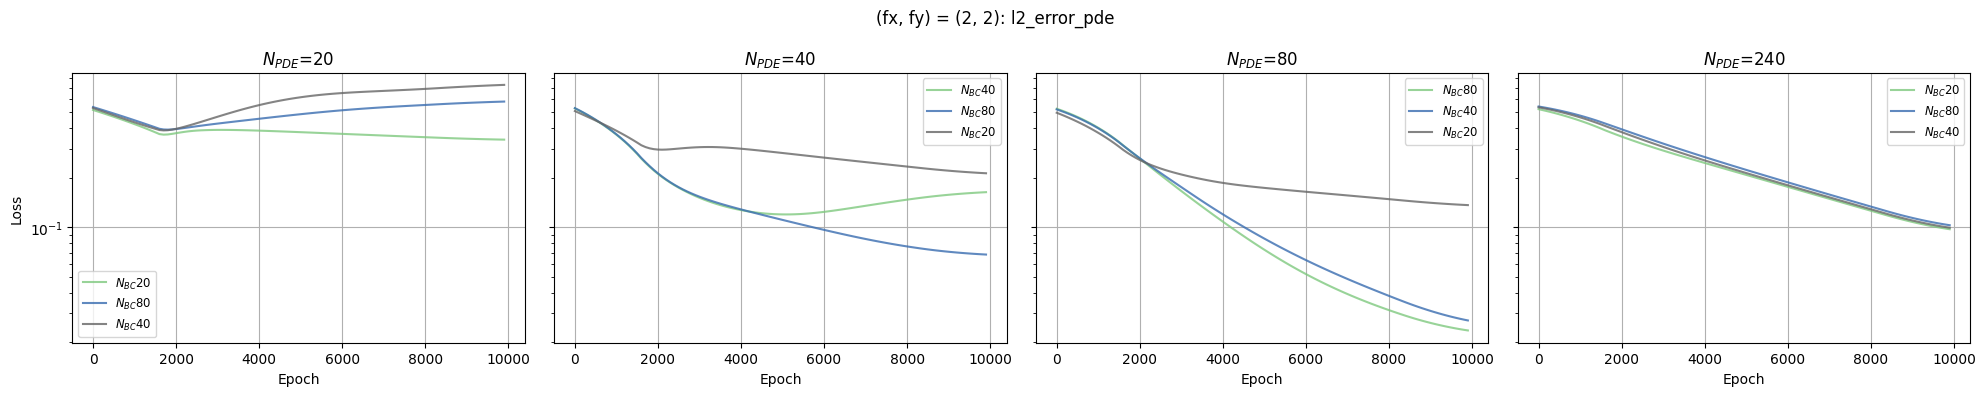

In [122]:

for k, v in regrouped_results.items():
    if k == "gn": continue
    print("""##################################################\n"""
          f"""# {k}\n"""
          """##################################################""")
    plot_regrouped_by_int(v, colors, metric_label="l2_error_pde", error_every=100, max_valid_steps=500)

##################################################
# sgd
##################################################


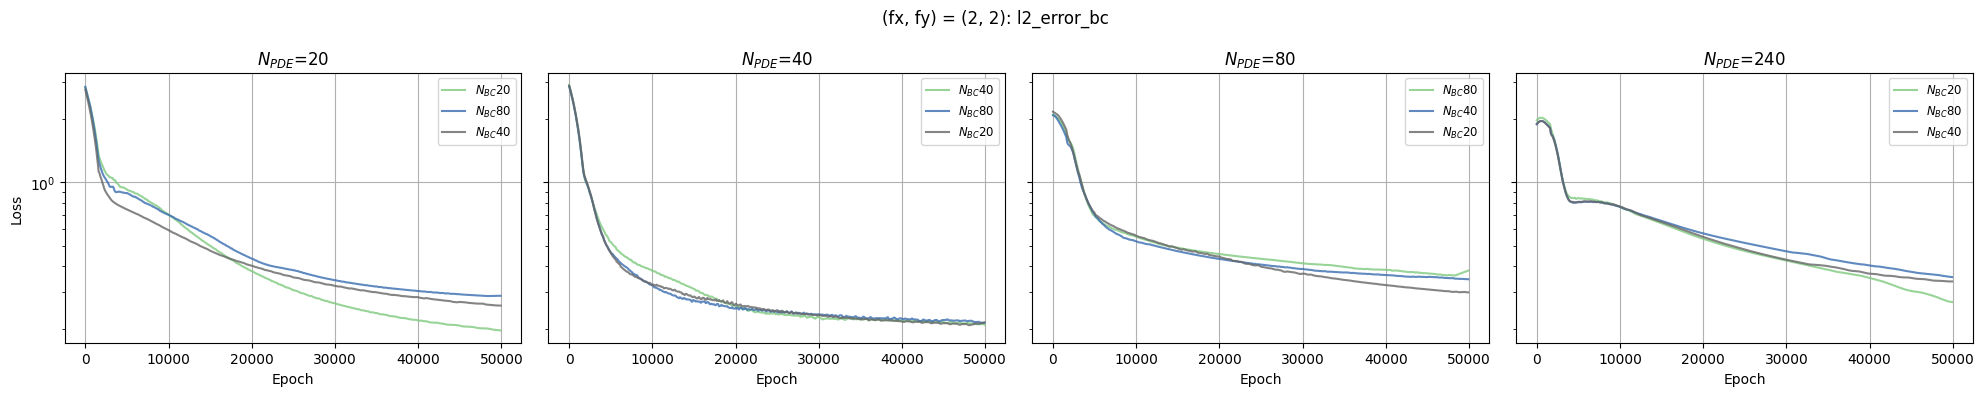

##################################################
# smw
##################################################


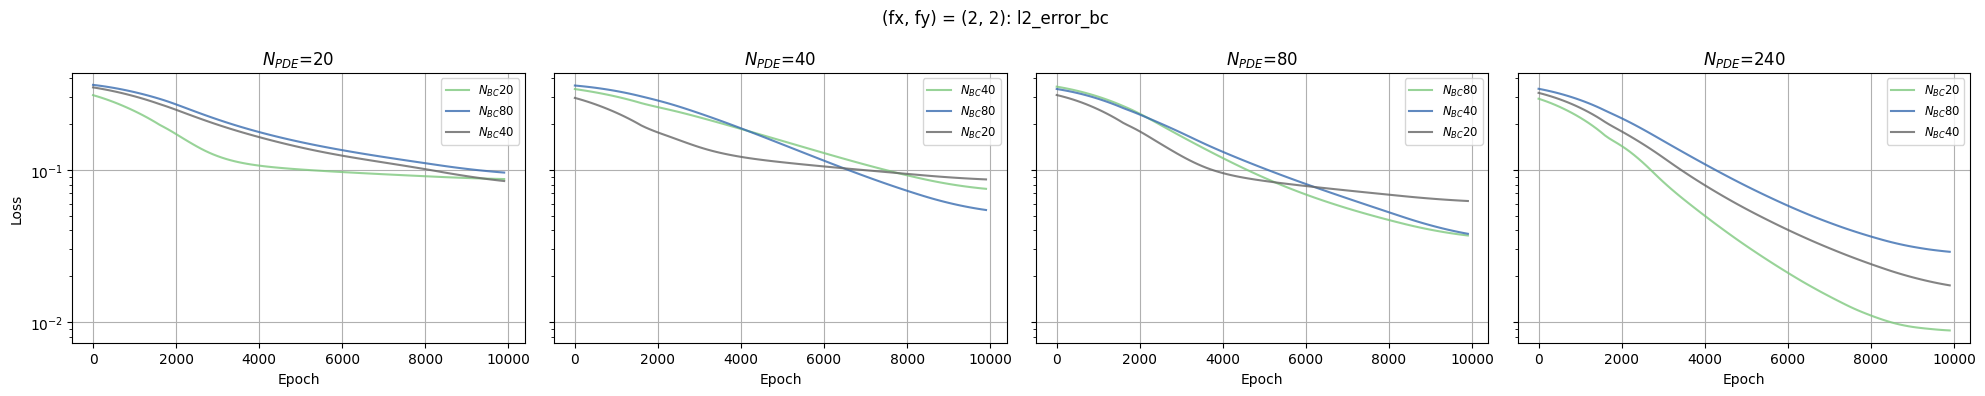

In [123]:

for k, v in regrouped_results.items():
    if k == "gn": continue
    print("""##################################################\n"""
          f"""# {k}\n"""
          """##################################################""")
    plot_regrouped_by_int(v, colors, metric_label="l2_error_bc", error_every=100, max_valid_steps=500)

The lowest metric value is achieved when the following boundary (BC) vs interior (PDE) point relationship is satisfied:

| Metric        | SGD                      | SMW                   |
| ------------- | ------------------------ | --------------------- |
| Training Loss | $N_{BC} \geq N_{PDE}$    | $N_{BC} \geq N_{PDE}$ |
| Total Error   | $N_{BC} \approx N_{PDE}$ | $N_{PDE} \geq N_{BC}$ |
| PDE Error     | $N_{BC} \approx N_{PDE}$ | $N_{PDE} \geq N_{BC}$ |
| BC error      | $N_{BC} \approx N_{PDE}$ | $N_{PDE} \geq N_{BC}$ |


Ranrdom throughts:
- the noise to signal ratio is a lot higer in SGD so the more BC points you can give the stronger the error reduction rates. However, the effect of varying the $N_{BC}:N_{PDE}$ does not influence convergence as strongly as in the SMW case.
- when preconditioning is used, the BC points get learned quickly (instantaneously? see y-axis of last two plot) but generalization does not happen readily. So we may need more interior points to make for it?